In [1]:
import pandas as pd
import json 


# train_data = pd.read_csv('/path/to/jais_efforts/poetry/data/de_dupped_train.tsv', sep='\t')
# test_data = pd.read_csv('/path/to/jais_efforts/poetry/data/de_dupped_test.tsv', sep='\t')

In [2]:
# ############### Number of data removed from training after deduplication  with training ###############
# intermediate_train_data = pd.read_csv('/path/to/jais_efforts/poetry/data/de_dupped_train_intermediate.tsv', sep='\t')
# after_dedup_train_data = pd.read_csv('/path/to/jais_efforts/poetry/data/de_dupped_train.tsv', sep='\t')

# print(f"Number of data removed from training after deduplication with training: {len(intermediate_train_data) - len(after_dedup_train_data)}")


/tmp/ipykernel_2047210/584254981.py:2: DtypeWarning: Columns (0,1,2,3,5,6,7,9,13,14,15,16,17,19) have mixed types. Specify dtype option on import or set low_memory=False.
  intermediate_train_data = pd.read_csv('/path/to/jais_efforts/poetry/data/de_dupped_train_intermediate.tsv', sep='\t')
/tmp/ipykernel_2047210/584254981.py:3: DtypeWarning: Columns (0,1,2,3,5,6,7,9,13,14,15,16,17,19) have mixed types. Specify dtype option on import or set low_memory=False.
  after_dedup_train_data = pd.read_csv('/path/to/jais_efforts/poetry/data/de_dupped_train.tsv', sep='\t')


Number of data removed from training after deduplication with training: 1036


In [3]:
import os

# Specify the path to the tokenization folder
tokenization_folder = 'data/processed'

# List all folders in the tokenization folder
folders = [f for f in os.listdir(tokenization_folder) if os.path.isdir(os.path.join(tokenization_folder, f))]
print(folders)

['poet_name__poet_era', 'poet_name__poet_description', 'poem_text__overall_explanation', 'poem_text__location', 'poem_text__verses_explanation', 'poem_text__meter', 'poem_text__poet_era', 'poem_text__poet_name', 'poet_name__location', 'poem_text__poem_title', 'poem_text__genre']


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
tokenization_folder = 'data/processed'
analysis_output_folder = './analysis'
os.makedirs(analysis_output_folder, exist_ok=True)

# Settings
top_n_poets = 20
sns.set(style="whitegrid")

# Define specific subdirectories
poem_text_dir = 'poem_text__poet_name'
genre_dir = 'poem_text__genre'
era_dir = 'poem_text__poet_era'
meter_dir = 'poem_text__meter'

# Load train/test helper
def load_split(folder_path):
    train_path = os.path.join(folder_path, 'train.tsv')
    test_path = os.path.join(folder_path, 'test.tsv')
    return {
        'train': pd.read_csv(train_path, sep='\t'),
        'test': pd.read_csv(test_path, sep='\t')
    }





In [4]:
print("Plotting poem length histograms...")
poem_folder_path = os.path.join(tokenization_folder, poem_text_dir)
splits = load_split(poem_folder_path)

Plotting poem length histograms...



Processing poem_text__poet_name - train...
Min tokens:  1
Max tokens:  31799
Mean tokens: 574.60


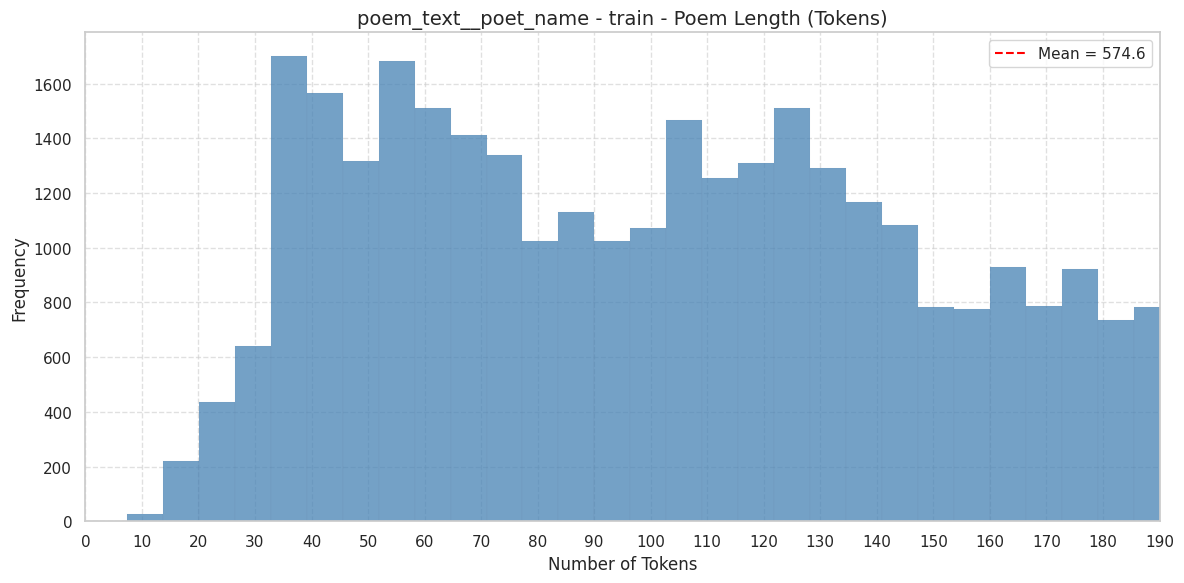


Processing poem_text__poet_name - test...
Min tokens:  44
Max tokens:  67972
Mean tokens: 1498.61


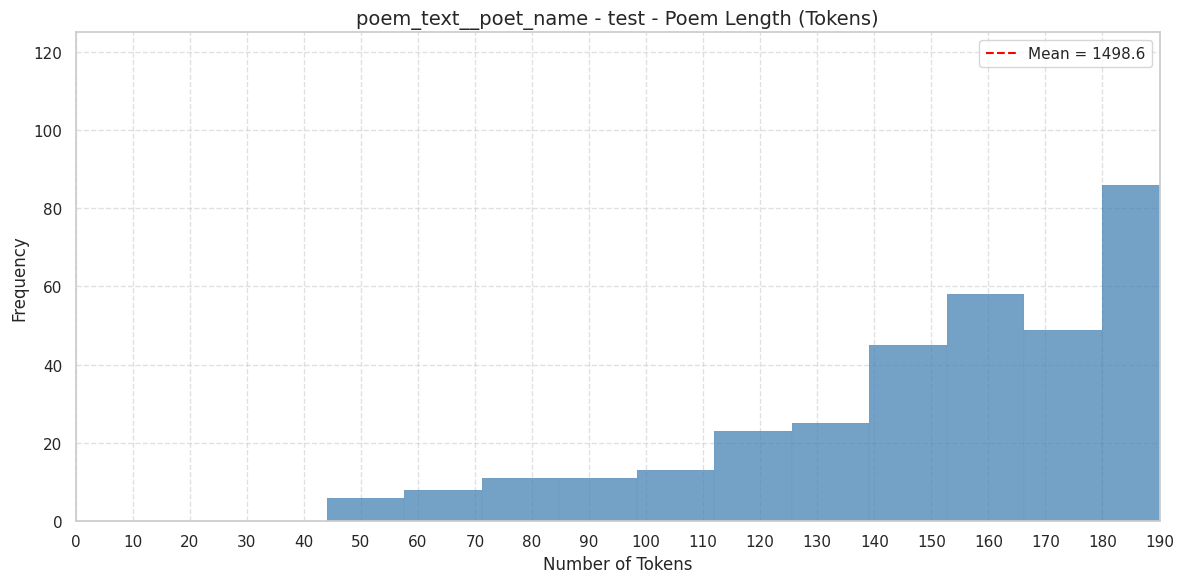

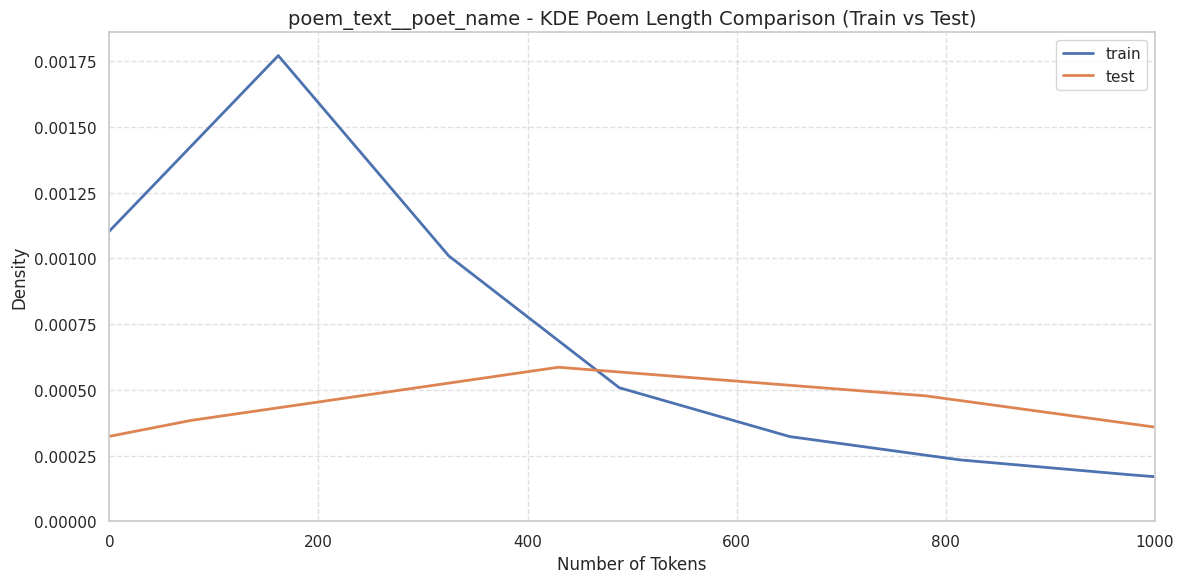

In [5]:
for split_name, df in splits.items():
    if 'poem_text_num_tokens' in df.columns:
        print(f"\nProcessing {poem_text_dir} - {split_name}...")

        token_lengths = df['poem_text_num_tokens'].dropna()

        # Compute statistics
        min_len = token_lengths.min()
        max_len = token_lengths.max()
        mean_len = token_lengths.mean()

        # Print statistics
        print(f"Min tokens:  {min_len}")
        print(f"Max tokens:  {max_len}")
        print(f"Mean tokens: {mean_len:.2f}")

        # Plot histogram
        plt.figure(figsize=(12, 6))
        sns.histplot(token_lengths, bins=5000, kde=False, color='steelblue', edgecolor='black')

        # Plot mean line
        plt.axvline(mean_len, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {mean_len:.1f}')

        # Title & labels
        plt.title(f'{poem_text_dir} - {split_name} - Poem Length (Tokens)', fontsize=14)
        plt.xlabel('Number of Tokens', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)

        # Limit x-axis
        plt.xlim(0, 150)
        plt.xticks(range(0, 200, 10))

        # Grid & legend
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()

        # Save and show
        plt.tight_layout()
        plt.savefig(os.path.join(
            analysis_output_folder,
            f'{poem_text_dir}_{split_name}_token_hist_zoomed.png'
        ))
        plt.show()
        plt.close()



plt.figure(figsize=(12, 6))

for split_name, df in splits.items():
    if 'poem_text_num_tokens' in df.columns:
        token_lengths = df['poem_text_num_tokens'].dropna()
        if len(token_lengths) >= 20:  # avoid noisy KDEs from tiny splits
            sns.kdeplot(token_lengths, label=split_name, linewidth=2)

plt.title(f'{poem_text_dir} - KDE Poem Length Comparison (Train vs Test)', fontsize=14)
plt.xlabel('Number of Tokens')
plt.ylabel('Density')
plt.xlim(0, 1000)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(analysis_output_folder, f'{poem_text_dir}_kde_token_comparison.png'))
plt.show()


Processing poem_text__poet_name - train...
Min verses:  0
Max verses:  891
Mean verses: 14.98


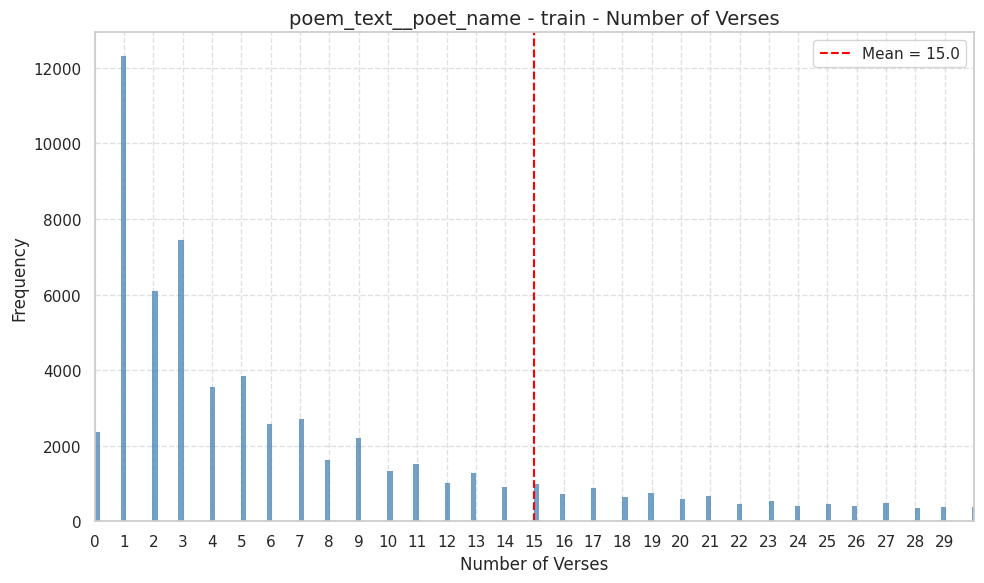


Processing poem_text__poet_name - test...
Min verses:  16
Max verses:  4558
Mean verses: 105.80


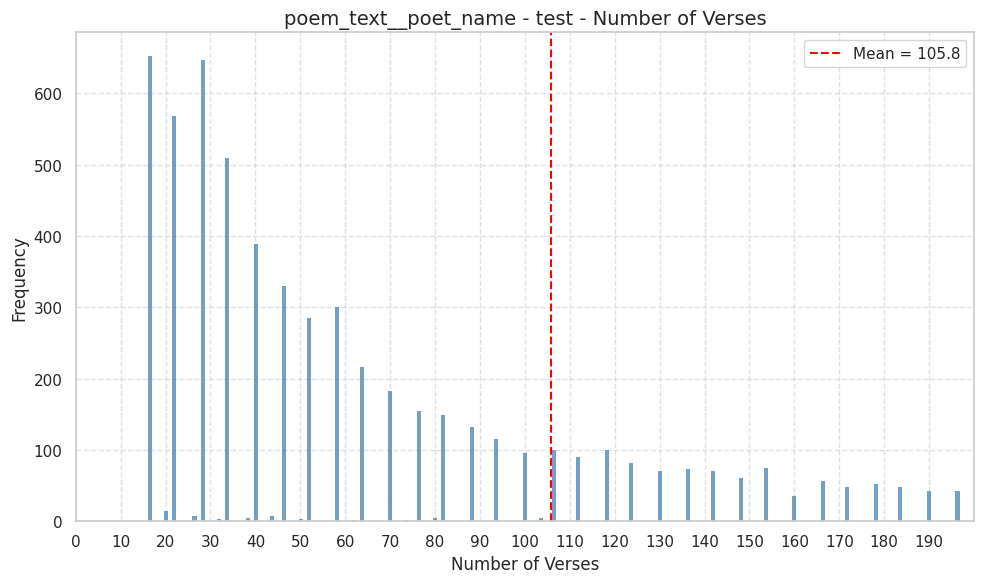

In [6]:
for split_name, df in splits.items():
    if 'poem_text' in df.columns:
        print(f"\nProcessing {poem_text_dir} - {split_name}...")

        # Count the number of verses using the '\n' separator
        verse_counts = df['poem_text'].astype(str).apply(lambda text: text.count('\n'))

        # Compute statistics
        min_verses = verse_counts.min()
        max_verses = verse_counts.max()
        mean_verses = verse_counts.mean()

        # Print statistics
        print(f"Min verses:  {min_verses}")
        print(f"Max verses:  {max_verses}")
        print(f"Mean verses: {mean_verses:.2f}")

        # Plot histogram
        plt.figure(figsize=(10, 6))
        sns.histplot(verse_counts, bins=5000, kde=False, color='steelblue', edgecolor='black')

        # Plot mean line
        plt.axvline(mean_verses, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {mean_verses:.1f}')

        # Limit x-axis
        if split_name == 'train':
            plt.xlim(0, 30)
            plt.xticks(range(0, 30, 1))
        else:
            plt.xlim(0, 200)
            plt.xticks(range(0, 200, 10))

        # Title & labels
        plt.title(f'{poem_text_dir} - {split_name} - Number of Verses', fontsize=14)
        plt.xlabel('Number of Verses', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)

        # Grid & legend
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()

        # Save and show
        plt.tight_layout()
        plt.savefig(os.path.join(
            analysis_output_folder,
            f'{poem_text_dir}_{split_name}_verse_hist.png'
        ))
        plt.show()
        plt.close()


In [19]:
with open("temp.txt", "w", encoding="utf-8") as f:
    for split_name, df in splits.items():
        if 'poem_text' in df.columns:
            print(f"\nVerse count distribution for {split_name} dataset:")
            verse_count_distribution = df['poem_text'].astype(str).apply(lambda text: text.count('\n')).value_counts().sort_index()
            print(verse_count_distribution)



        # Get the first and last verse counts
        first_verse_count = verse_count_distribution.index[0]
        last_verse_count = verse_count_distribution.index[-1]

        for verse_count in range(16, last_verse_count + 1):

            if verse_count < 20:
                f.write(f"\nVerse Count: {verse_count}\n")
                
                for split_name, df in splits.items():
                    if 'poem_text' in df.columns:
                        f.write(f"{split_name.capitalize()} Samples:\n")
                        subset = df[df['poem_text'].astype(str).apply(lambda text: text.count('\n')) == verse_count]
                        sampled_subset = subset.sample(n=min(5, len(subset)), random_state=42)  # Sample up to 5 rows
                        
                        for _, row in sampled_subset.iterrows():
                            f.write(f"{row['poem_text']}\n")
                            f.write("-" * 80 + "\n")


Verse count distribution for train dataset:
poem_text
0       2375
1      12324
2       6086
3       7440
4       3563
       ...  
575        1
607        1
754        1
774        2
891        1
Name: count, Length: 316, dtype: int64

Verse count distribution for test dataset:
poem_text
16      653
20       14
22      568
26        8
28      647
       ... 
1288      1
1354      1
1558      1
1732      1
4558      1
Name: count, Length: 154, dtype: int64


In [10]:
grouped_samples = {
    split_name: df for split_name, df in splits.items() if 'poem_text' in df.columns
}

with open("temp.txt", "w", encoding="utf-8") as f:
    for verse_count in sorted(verse_counts.unique()):
        if 0 <= verse_count <= 5:
            f.write(f"Verse Count: {verse_count}\n")
            f.write("Train Samples:\n")
            if 'train' in grouped_samples:
                train_samples = grouped_samples['train']
                train_subset = train_samples[train_samples['poem_text'].str.count('\n') == verse_count]
                for _, row in train_subset.iterrows():
                    f.write(f"{row['poem_text']}\n")
            
            f.write("Test Samples:\n")
            if 'test' in grouped_samples:
                test_samples = grouped_samples['test']
                test_subset = test_samples[test_samples['poem_text'].str.count('\n') == verse_count]
                for _, row in test_subset.iterrows():
                    f.write(f"{row['poem_text']}\n")
            
            f.write("\n")

In [7]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display

font_path = "/usr/share/fonts/opentype/fonts-hosny-amiri/Amiri-Regular.ttf"  # Update if needed
amiri_font = fm.FontProperties(fname=font_path)
# Use an Arabic-supporting font (adjust the path if needed)
# rcParams['font.family'] = 'Amiri'  # Or 'Amiri', 'Noto Naskh Arabic', etc.

In [8]:
from matplotlib import font_manager
import os

fonts = font_manager.findSystemFonts(fontpaths=None, fontext='ttf')
amiri_fonts = [f for f in fonts if "amiri" in f.lower()]

print("Found Amiri fonts:")
for f in amiri_fonts:
    print(f)


Found Amiri fonts:
/usr/share/fonts/opentype/fonts-hosny-amiri/Amiri-BoldSlanted.ttf
/usr/share/fonts/opentype/fonts-hosny-amiri/AmiriQuran.ttf
/usr/share/fonts/opentype/fonts-hosny-amiri/AmiriQuranColored.ttf
/usr/share/fonts/opentype/fonts-hosny-amiri/Amiri-Slanted.ttf
/usr/share/fonts/opentype/fonts-hosny-amiri/Amiri-Regular.ttf
/usr/share/fonts/opentype/fonts-hosny-amiri/Amiri-Bold.ttf


Plotting bar plots for genre, era, meter...


/tmp/ipykernel_21130/2056455346.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontproperties=amiri_font)


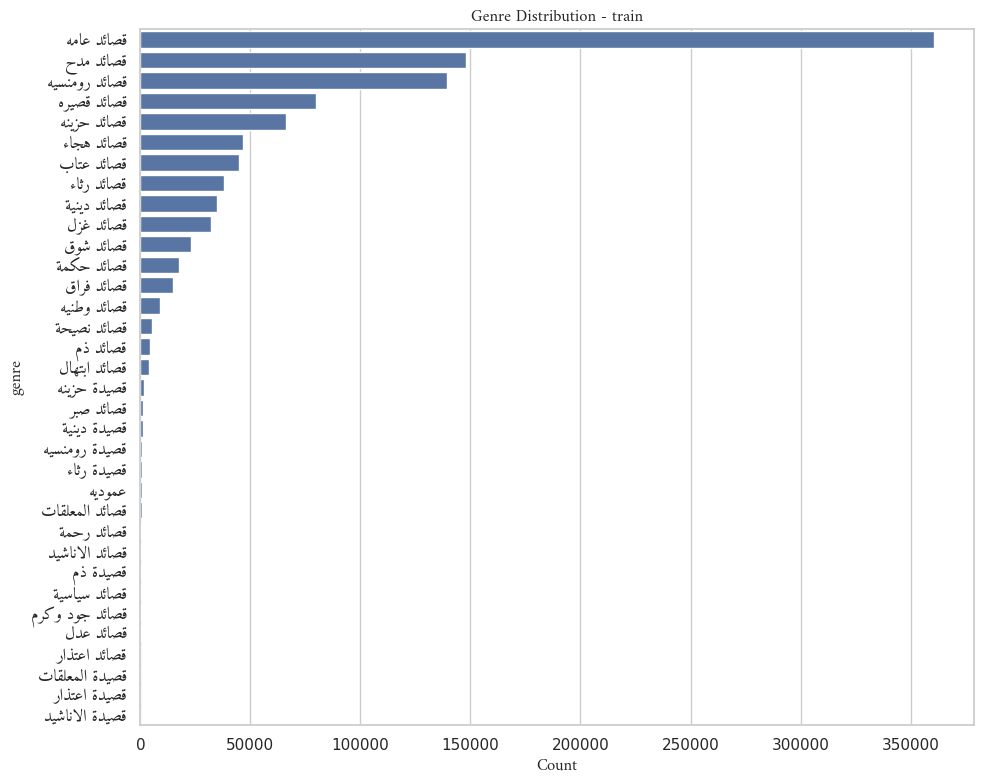

/tmp/ipykernel_21130/2056455346.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontproperties=amiri_font)


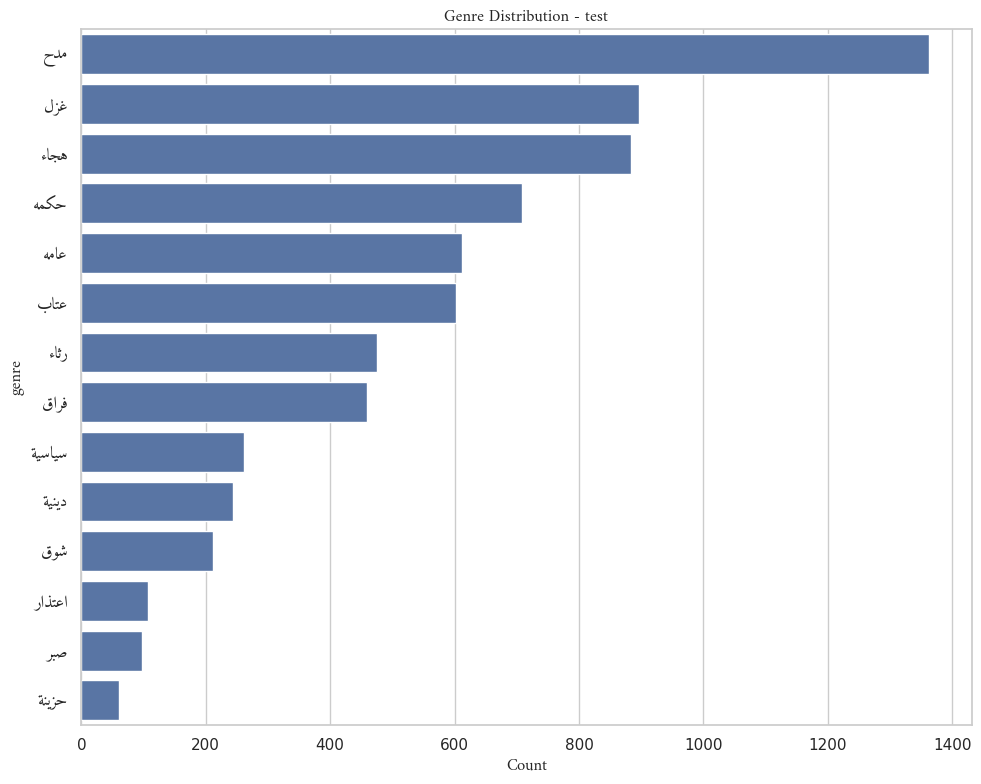

/tmp/ipykernel_21130/2056455346.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontproperties=amiri_font)


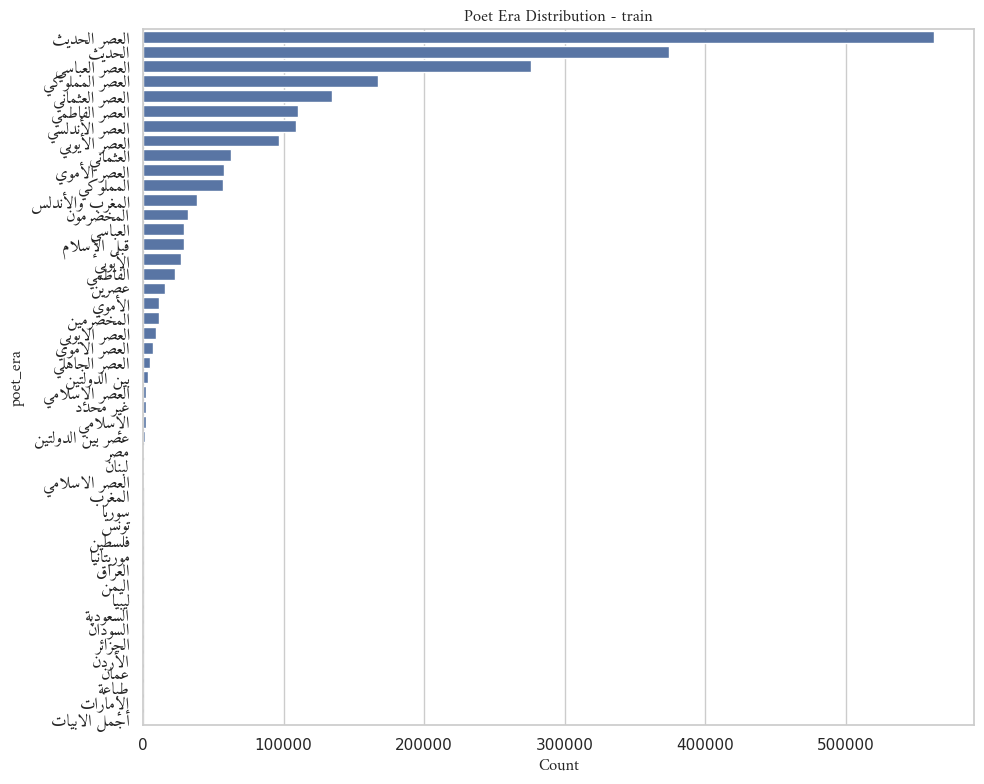

/tmp/ipykernel_21130/2056455346.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontproperties=amiri_font)


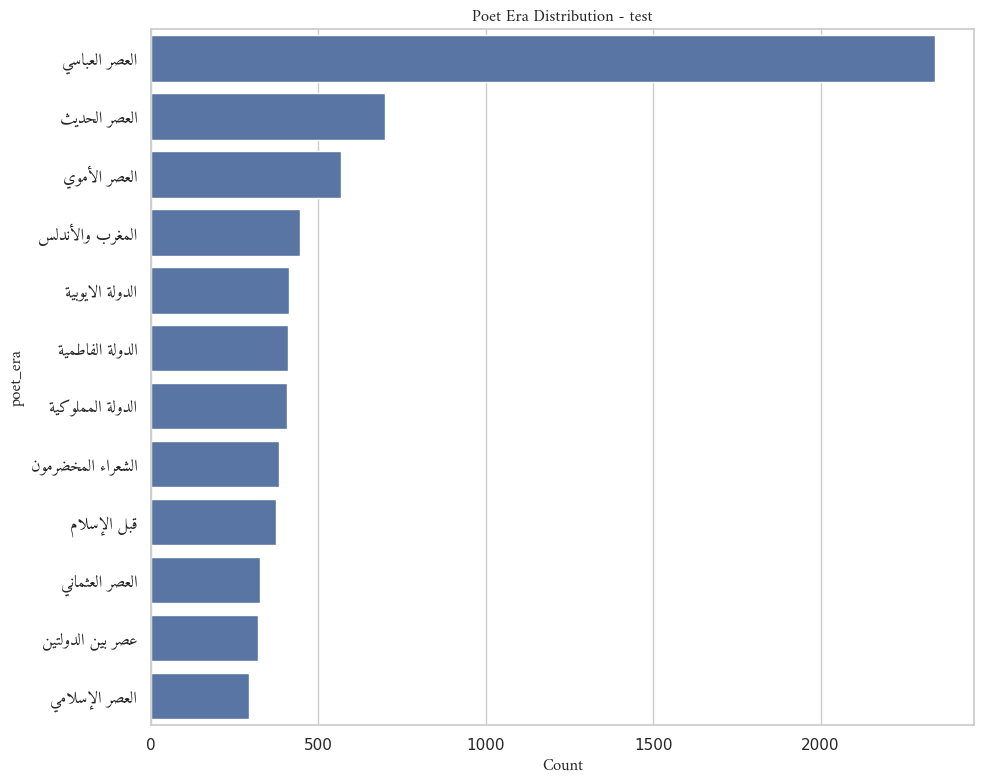

/tmp/ipykernel_21130/2056455346.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontproperties=amiri_font)


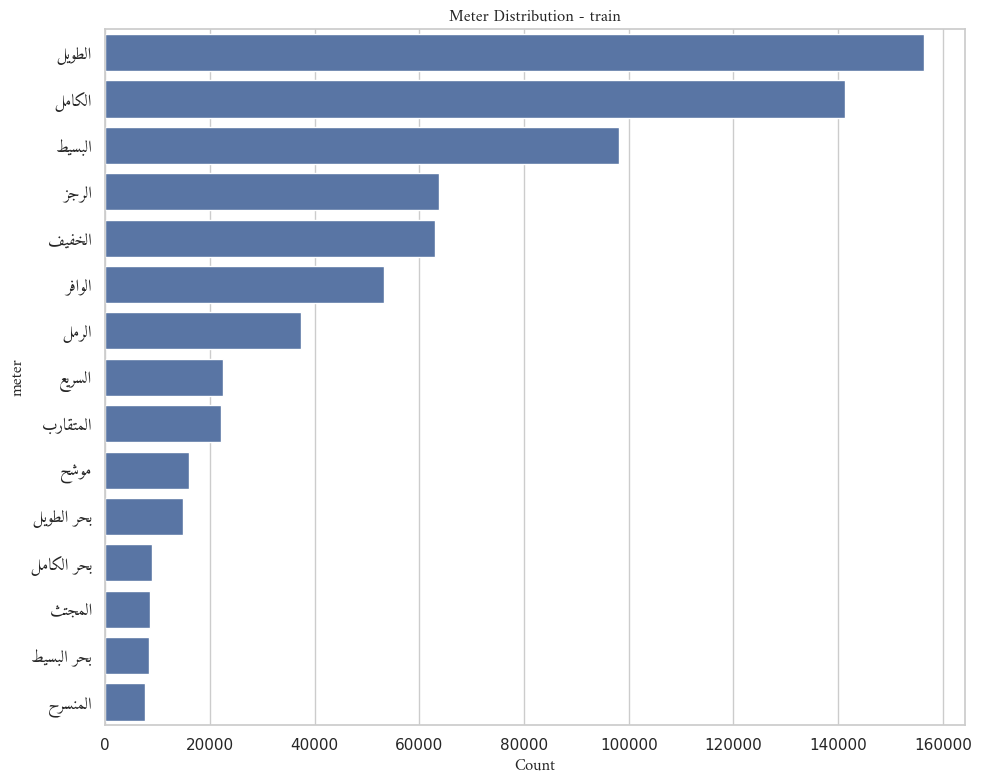

/tmp/ipykernel_21130/2056455346.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontproperties=amiri_font)


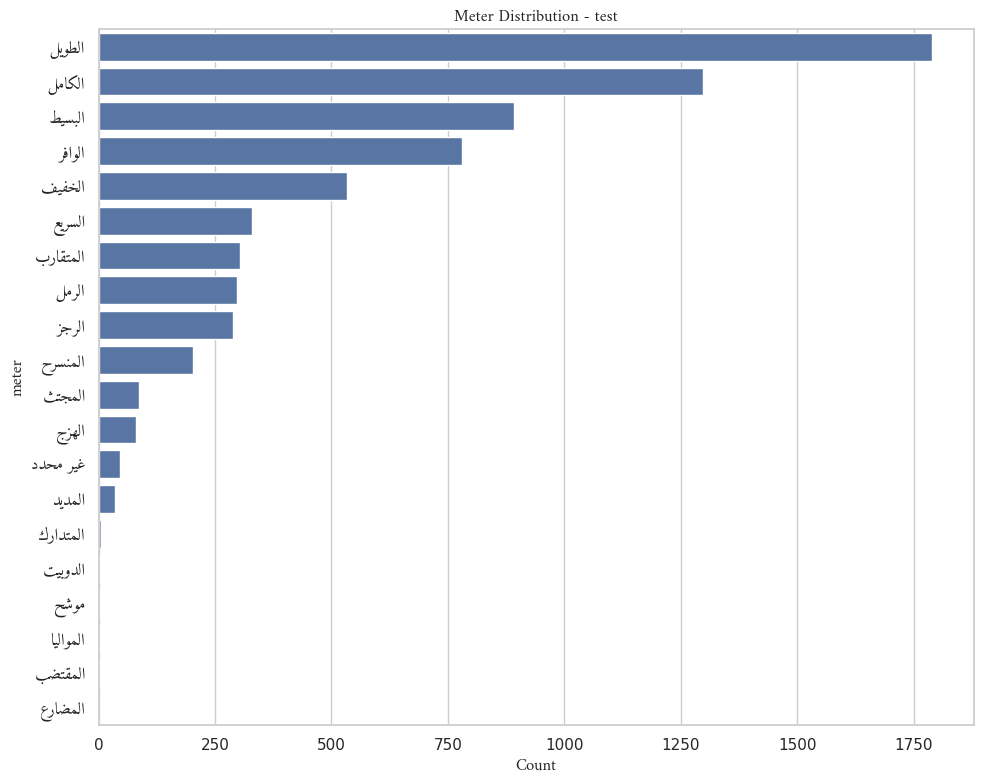

In [9]:
def plot_bar(folder, column, title, filename_prefix):
    folder_path = os.path.join(tokenization_folder, folder)
    splits = load_split(folder_path)

    for split_name, df in splits.items():
        if column in df.columns:
            # Filter top 10 for meter & train only
            if column == 'meter' and split_name == 'train':
                top_values = df[column].value_counts().nlargest(15).index
                df = df[df[column].isin(top_values)]


            plt.figure(figsize=(10, 8))

            # Plot
            ax = sns.countplot(data=df, y=column, order=df[column].value_counts().index)

            # Reshape and bidi y-tick labels
            labels = [get_display(arabic_reshaper.reshape(str(tick.get_text()))) for tick in ax.get_yticklabels()]
            ax.set_yticklabels(labels, fontproperties=amiri_font)

            # Titles and labels reshaped
            reshaped_title = get_display(arabic_reshaper.reshape(f'{title} Distribution - {split_name}'))
            reshaped_xlabel = get_display(arabic_reshaper.reshape("Count"))
            reshaped_ylabel = get_display(arabic_reshaper.reshape(column))

            plt.title(reshaped_title, fontsize=14, fontproperties=amiri_font)
            plt.xlabel(reshaped_xlabel, fontsize=12, fontproperties=amiri_font)
            plt.ylabel(reshaped_ylabel, fontsize=12, fontproperties=amiri_font)

            plt.tight_layout()
            plt.savefig(os.path.join(analysis_output_folder, f'{filename_prefix}_{split_name}_bar.png'))
            plt.show()
            plt.close()

            
print("Plotting bar plots for genre, era, meter...")
plot_bar(genre_dir, 'genre', 'Genre', 'genre')
plot_bar(era_dir, 'poet_era', 'Poet Era', 'poet_era')
plot_bar(meter_dir, 'meter', 'Meter', 'meter')

Plotting top poets...


/tmp/ipykernel_21130/1043014692.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontproperties=amiri_font)


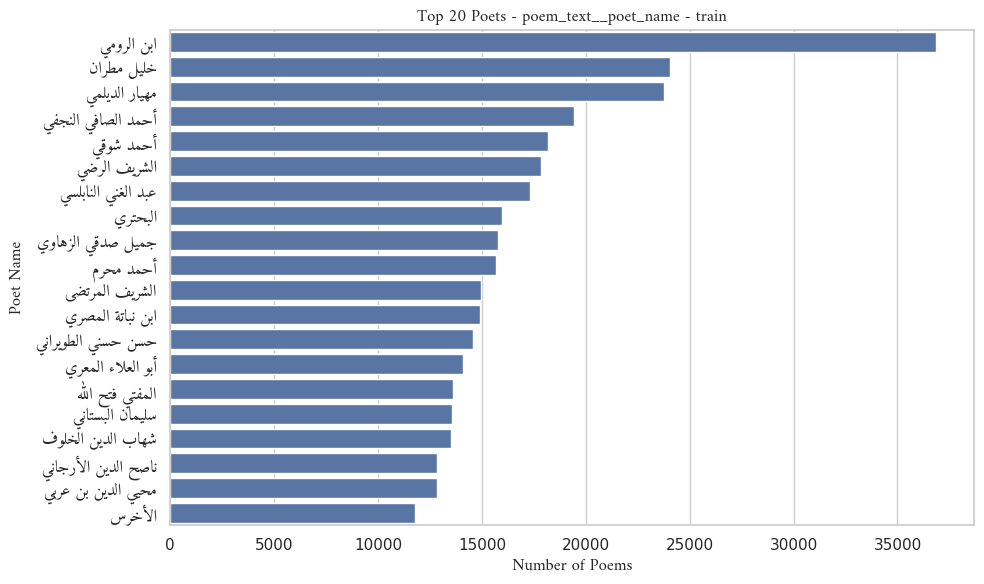

/tmp/ipykernel_21130/1043014692.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontproperties=amiri_font)


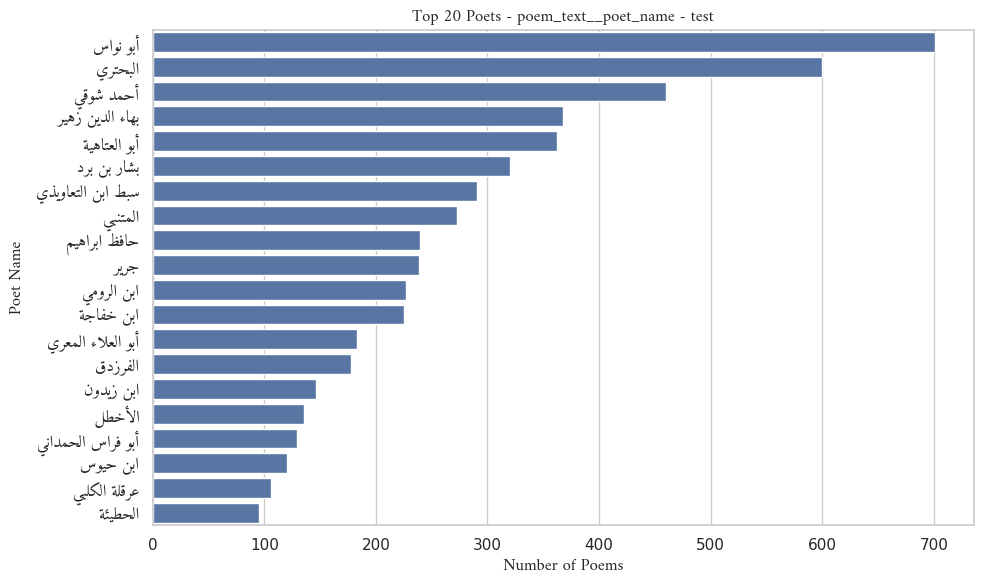

In [10]:
%matplotlib inline

### 3. Top N poets from poem_text__poem_title
print("Plotting top poets...")
for split_name, df in splits.items():
    if 'poet_name' in df.columns:
        top_poets = df['poet_name'].value_counts().nlargest(top_n_poets)
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x=top_poets.values, y=top_poets.index)

        # Apply reshaping and bidi to y-tick labels
        labels = [get_display(arabic_reshaper.reshape(str(tick.get_text()))) for tick in ax.get_yticklabels()]
        ax.set_yticklabels(labels, fontproperties=amiri_font)

        # Apply reshaping to title and axis labels
        reshaped_title = get_display(arabic_reshaper.reshape(f'Top {top_n_poets} Poets - {poem_text_dir} - {split_name}'))
        reshaped_xlabel = get_display(arabic_reshaper.reshape("Number of Poems"))
        reshaped_ylabel = get_display(arabic_reshaper.reshape("Poet Name"))

        plt.title(reshaped_title, fontsize=14, fontproperties=amiri_font)
        plt.xlabel(reshaped_xlabel, fontsize=12, fontproperties=amiri_font)
        plt.ylabel(reshaped_ylabel, fontsize=12, fontproperties=amiri_font)

        plt.tight_layout()
        plt.savefig(os.path.join(analysis_output_folder, f'{poem_text_dir}_{split_name}_top_poets.png'))
        plt.show()  # Ensure the plot is displayed
        plt.close()
